<a href="https://colab.research.google.com/github/zohrehasadi00/automatic_image_analysis/blob/main/notebooks/SkinLesionTriage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reproducible Pipeline

In [96]:
# import collection

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

from scipy.sparse import find

In [97]:
#set seed for reproducibility
random_state = 42
torch.manual_seed(42)
np.random.seed(42)

In [98]:
# connect Drive for data
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Exploration

In this section you will find:


*   the classification labels (malignant and benign) are converted into numerical values
* a sanity check is conducted to ensure that no image files listed in the metadata are missing
* descriptive statistic on the distribution of the complete dataset




In [99]:
#path to image data
data_raw =[
    '/content/drive/MyDrive/AIA_SkinLesion_Projekt/data/raw/HAM10000_images_part_1',
    '/content/drive/MyDrive/AIA_SkinLesion_Projekt/data/raw/HAM10000_images_part_2'
    ]

# load metadata
csv_path = '/content/drive/MyDrive/AIA_SkinLesion_Projekt/HAM10000_metadata.csv'
df_metadata = pd.read_csv(csv_path)


In [100]:
##### Recode 'mel' (melanoma) = 1, benign = 0 #####

df_metadata['label'] = (df_metadata['dx'] == 'mel').astype(int)

#save converted file back to Drive
output_dir = '/content/drive/MyDrive/AIA_SkinLesion_Projekt'
os.makedirs(output_dir, exist_ok=True)

df_metadata.to_csv(os.path.join(output_dir, 'HAM10000_metadata_converted.csv'), index=False)


In [101]:
##### Sanity check for missing image files #####
missing = []

for idx in range(len(df_metadata)):
    img_id = df_metadata.iloc[idx]['image_id']
    img_name = img_id + '.jpg'
    found = any(os.path.exists(os.path.join(d, img_name)) for d in data_raw)
    if not found:
        missing.append(img_name)

print(f"{len(missing)} images could not be found")
print(missing[:10])




0 images could not be found
[]


Shape of data : (10015, 8)
Nummber of dimensions : 2

Class distribution (0=benign, 1=melanoma):
label
0    8902
1    1113
Name: count, dtype: int64


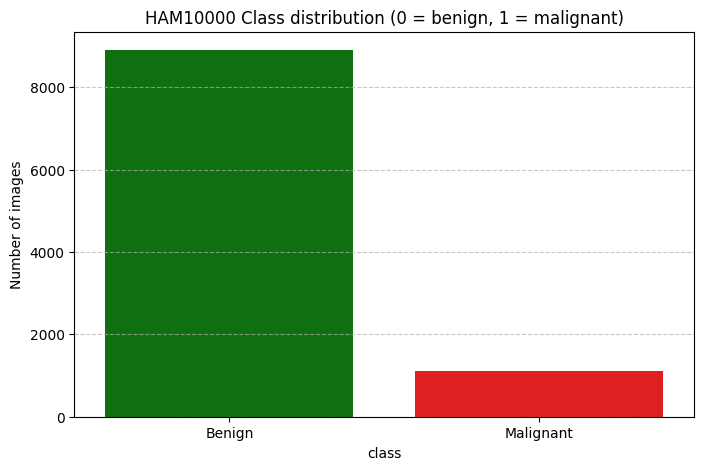


Impression of the data:


,lesion_id,image_id,dx,dx_type,age,sex,localization,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,0
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,0
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,0
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,0
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,0


In [102]:
##### plot class distribution #####
def plotClassDistribution(dataset):
  plt.figure(figsize=(8, 5))
  sns.countplot(x='label', data=dataset, hue='label', palette=['green', 'red'], legend=False)
  plt.title('HAM10000 Class distribution (0 = benign, 1 = malignant)')
  plt.xlabel('class')
  plt.ylabel('Number of images')
  plt.xticks([0, 1], ['Benign', 'Malignant'])
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.show()


print(f"Shape of data : {df_metadata.shape}")
print(f"Nummber of dimensions : {df_metadata.ndim}")
print(f"\nClass distribution (0=benign, 1=melanoma):\n{df_metadata['label'].value_counts()}")
plotClassDistribution(df_metadata)

print(f"\nImpression of the data:")
df_metadata.head()


# Split training, test and validation set

In this section the data is split to train, validation and test set. All splits are saved in distinct csv-files on Drive, so that we can use for both pipelines the same splits.

**Train set**: Is used for training

**Validation set** (12.5% of the train set): Is used for hyperparameter training

**Test set** (20% of the original dataset): Is used for evaluating the model's performance


In [103]:

train_val_df, test_df = train_test_split(df_metadata, test_size=0.20, stratify=df_metadata['label'], random_state=random_state) # set seed

# create validation set for hyperparameter fine tuning
train_df, val_df = train_test_split(train_val_df, test_size=0.125, stratify=train_val_df['label'], random_state=random_state)

print(f"training set: {len(train_df)}")
print(f"validation set: {len(val_df)}")
print(f"test set: {len(test_df)}")

##save split sets to Drive
output_dir = '/content/drive/MyDrive/AIA_SkinLesion_Projekt/splits'
os.makedirs(output_dir, exist_ok=True)

train_df.to_csv(os.path.join(output_dir, 'train.csv'), index=False)
val_df.to_csv(os.path.join(output_dir, 'val.csv'), index=False)
test_df.to_csv(os.path.join(output_dir, 'test.csv'), index=False)

training set: 7010
validation set: 1002
test set: 2003


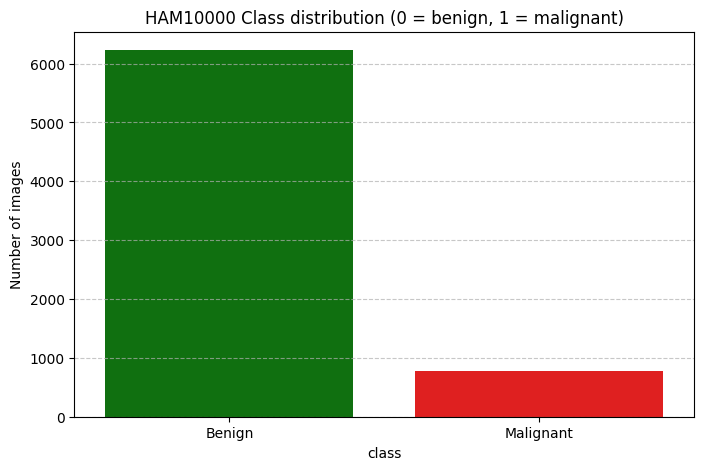

                age   sex localization
count   6973.000000  7010         7010
unique          NaN     3           15
top             NaN  male         back
freq            NaN  3792         1527
mean      51.890865   NaN          NaN
std       17.007532   NaN          NaN
min        0.000000   NaN          NaN
25%       40.000000   NaN          NaN
50%       50.000000   NaN          NaN
75%       65.000000   NaN          NaN
max       85.000000   NaN          NaN


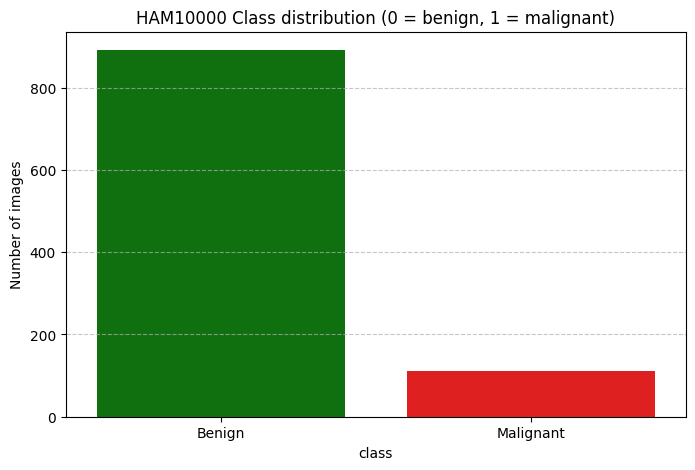

               age   sex     localization
count   995.000000  1002             1002
unique         NaN     3               14
top            NaN  male  lower extremity
freq           NaN   526              221
mean     51.467337   NaN              NaN
std      16.771865   NaN              NaN
min       0.000000   NaN              NaN
25%      40.000000   NaN              NaN
50%      50.000000   NaN              NaN
75%      65.000000   NaN              NaN
max      85.000000   NaN              NaN


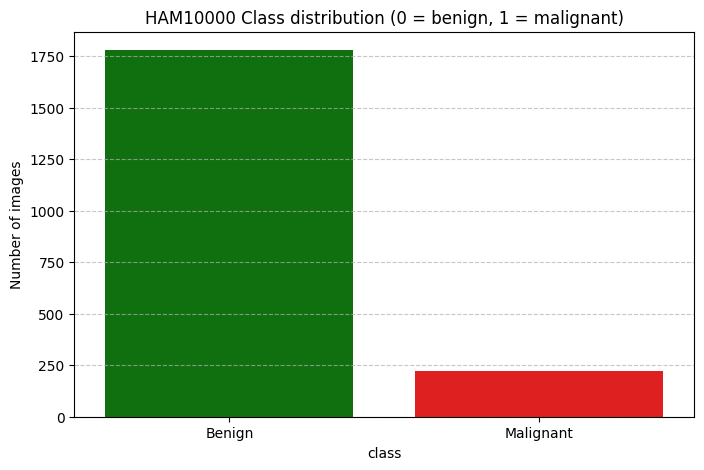

                age   sex localization
count   1990.000000  2003         2003
unique          NaN     3           14
top             NaN  male         back
freq            NaN  1088          468
mean      51.967337   NaN          NaN
std       16.935581   NaN          NaN
min        0.000000   NaN          NaN
25%       40.000000   NaN          NaN
50%       50.000000   NaN          NaN
75%       65.000000   NaN          NaN
max       85.000000   NaN          NaN


In [104]:
#explore splits
dataset = [train_df, val_df, test_df]


for df_split in dataset:
  plotClassDistribution(df_split)
  print(df_split[["age", "sex", "localization"]].describe(include="all"))